In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('../data/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
print(df.shape)
df.describe()

(500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000


Dataset Overview

The dataset contains 500 customer records with 6 numerical features related to Spending Behavior and engagement

Overall the dataset shows strong variation across features.making it suitable for clustering

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

K-Means clustering is distance based, So features must be on the same scale. without scaling, variables with larger values like annual spend would dominate the clustering process. StandardScaler ensures all features contribute equally

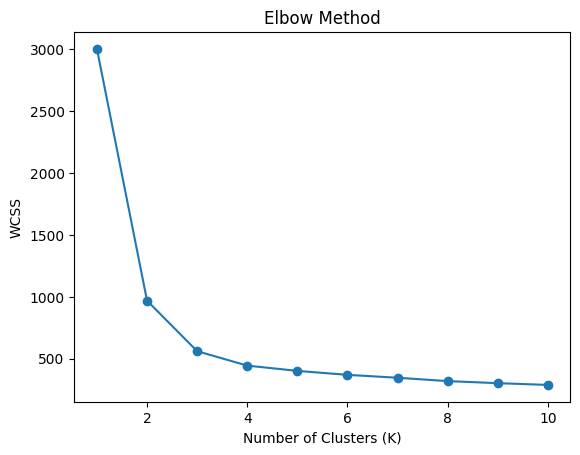

In [5]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

Elbow Method for Optimal K

The elbow plot shows a sharp decrease from K=1 to K=3, after which the curve starts to flatten. this indicates that the improvement in clustering reduces beyond K=3.

Therefore the optimal number of clusters is chosen as K = 3, as it balances model simplicity and clustering performance.

In [6]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [7]:
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                         columns=df.columns[:-1])

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Based on the cluster centroids, we can interpret the customer segments as follows:

Cluster 0: Younger customers with low annual spend and small basket sizes but frequent visits. These seem to be regular but low-value shoppers.

Cluster 1: Older customers with very high annual spend and large basket sizes, but infrequent visits. These are likely premium or bulk buyers who shop occasionally but spend heavily.

Cluster 2: Mid-aged customers with moderate spending, average visit frequency, and balanced basket sizes. this group can be considered as typical average customers.

These segments can help businesses target different customer groups with tailored marketing strategies

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.83560354 0.05568764]


In [9]:
#PCA loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 has strong positive contributions from Features like annual spend, basket size, and number of categories purchased, indicating it represents overall customer value or spending behaviour.

PC2 is heavily influenced by days since last visit suggesting it captures customer recency or inactivity patterns.
Together, these components help differentiate high-value active customers from low-engagement/inactive ones.

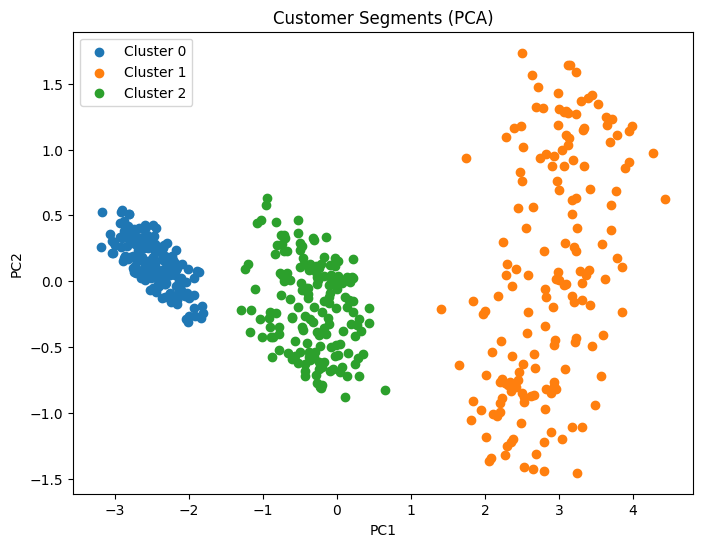

In [10]:
#Cluster visualization
plt.figure(figsize=(8,6))

for i in range(k):
    plt.scatter(
        X_pca[df['cluster']==i, 0],
        X_pca[df['cluster']==i, 1],
        label=f"Cluster {i}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA)")
plt.legend()
plt.show()

The PCA scatter plot shows three clearly separated segments, indicating that the clustering has performed effectively

Cluster 1 (orange one) represents high-value customers with higher spending and engagement, while Cluster 0 (blue one) consists of low-spending but frequent visitors.

Cluster 2 (middle - green one) appears to represent moderate customers with average spending and activity levels.

The clear separation between clusters suggests that the chosen features successfully capture meaningful differences in customer behaviour.